# Importing libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Bidirectional,GRU,Dense
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from tensorflow.keras.callbacks import EarlyStopping
import plotly.graph_objects as go
from statsmodels.tsa.seasonal import seasonal_decompose
import plotly.subplots as sp
import tensorflow as tf

In [3]:
data=pd.read_csv('/content/DailyDelhiClimateTrain.csv')
data.head()

,date,meantemp,humidity,wind_speed,meanpressure
0,2013-01-01,10.000000,84.500000,0.000000,1015.666667
1,2013-01-02,7.400000,92.000000,2.980000,1017.800000
2,2013-01-03,7.166667,87.000000,4.633333,1018.666667
3,2013-01-04,8.666667,71.333333,1.233333,1017.166667
4,2013-01-05,6.000000,86.833333,3.700000,1016.500000


In [4]:
data.index=pd.to_datetime(data['date'])
data.drop(['date'],axis=1,inplace=True)

# EDA

In [5]:
fig = px.line(data, x=data.index, y=["meantemp"],
              title="weather temperature  over time",range_x=['2013-01-01','2017-01-01'])
fig.update_xaxes(
    rangeslider_visible=True,

    rangeselector=dict(
    buttons=list([
    dict(count=1, label="1m", step="month", stepmode="todate"),
    dict(count=6, label="6m", step="month", stepmode="backward"),
    dict(count=1, label="YTD", step="year", stepmode="todate"),
    dict(count=1, label="Y", step="year", stepmode="backward"),
    dict(count=2, label="2y", step="year", stepmode="backward"),
    dict(step="all")
    ])
    )
    )

fig.show()

In [6]:
fig = px.line(data, x=data.index, y=["humidity"],
              title="weather humdity  over time",range_x=['2013-01-01','2017-01-01'])
fig.update_xaxes(
    rangeslider_visible=True,

    rangeselector=dict(
    buttons=list([
    dict(count=1, label="1m", step="month", stepmode="todate"),
    dict(count=6, label="6m", step="month", stepmode="backward"),
    dict(count=1, label="YTD", step="year", stepmode="todate"),
    dict(count=1, label="Y", step="year", stepmode="backward"),
    dict(count=2, label="2y", step="year", stepmode="backward"),
    dict(step="all")
    ])
    )
    )

fig.show()

In [7]:
fig = px.line(data, x=data.index, y=["meanpressure"],
              title="weather mean pressure  over time",range_x=['2013-01-01','2017-01-01'])
fig.update_xaxes(
    rangeslider_visible=True,

    rangeselector=dict(
    buttons=list([
    dict(count=1, label="1m", step="month", stepmode="todate"),
    dict(count=6, label="6m", step="month", stepmode="backward"),
    dict(count=1, label="YTD", step="year", stepmode="todate"),
    dict(count=1, label="Y", step="year", stepmode="backward"),
    dict(count=2, label="2y", step="year", stepmode="backward"),
    dict(step="all")
    ])
    )
    )

fig.show()

In [8]:

#############################################make sure to check this cell
result = seasonal_decompose(data['meantemp'], model='additive', period=365)

fig = sp.make_subplots(rows=2, cols=1, shared_xaxes=True,
                       subplot_titles=['Observed', 'Trend'])

fig.add_trace(go.Scatter(x=data.index, y=result.observed, mode='lines', name='Observed'), row=1, col=1)
fig.add_trace(go.Scatter(x=data.index, y=result.trend, mode='lines', name='Trend'), row=2, col=1)

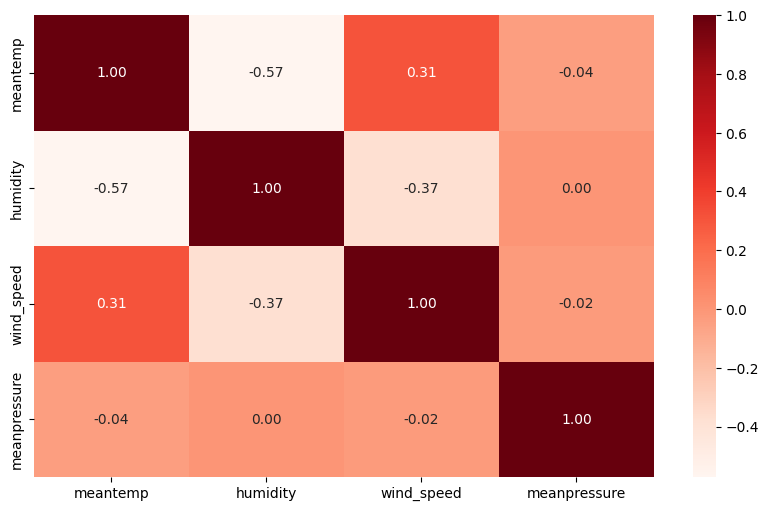

In [9]:
plt.figure(figsize=(10,6))
sns.heatmap(data.corr(), fmt=".2f", annot=True, cmap='Reds')
plt.show()

# Data processing

In [10]:
data.info()
print('-'*100+'\n')


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1462 entries, 2013-01-01 to 2017-01-01
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   meantemp      1462 non-null   float64
 1   humidity      1462 non-null   float64
 2   wind_speed    1462 non-null   float64
 3   meanpressure  1462 non-null   float64
dtypes: float64(4)
memory usage: 57.1 KB
----------------------------------------------------------------------------------------------------



In [11]:
print(data.isnull().sum())
print("-"*50)
print(data.isna().sum())

meantemp        0
humidity        0
wind_speed      0
meanpressure    0
dtype: int64
--------------------------------------------------
meantemp        0
humidity        0
wind_speed      0
meanpressure    0
dtype: int64


In [12]:
columns=data.columns
for i in columns :
  print(i)

meantemp
humidity
wind_speed
meanpressure


In [76]:
from sklearn.preprocessing import  MinMaxScaler
minmax_scaler = MinMaxScaler()
temp_scaler=MinMaxScaler()
data['humidity'] = minmax_scaler.fit_transform(data[['humidity']])
data['wind_speed'] = minmax_scaler.fit_transform(data[['wind_speed']])
data['meanpressure'] = minmax_scaler.fit_transform(data[['meanpressure']])
"""
the error occurs because the user is trying to access multiple columns in the DataFrame data using a single key ('humidity', 'wind_speed', 'meanpressure'). This is not allowed in Pandas, as the [] operator only accepts a single key or a list of keys.
('humidity', 'wind_speed', 'meanpressure')
"""

data["meantemp"]=temp_scaler.fit_transform(data[["meantemp"]])
data

,meantemp,humidity,wind_speed,meanpressure
date,,,,
2013-01-01,0.122271,0.820957,0.000000,0.132603
2013-01-02,0.042795,0.907591,0.070583,0.132881
2013-01-03,0.035662,0.849835,0.109743,0.132994
2013-01-04,0.081514,0.668867,0.029212,0.132799
2013-01-05,0.000000,0.847910,0.087636,0.132712
...,...,...,...,...
2016-12-28,0.342890,0.630865,0.084032,0.132590
2016-12-29,0.282387,0.859736,0.142113,0.132764
2016-12-30,0.247453,0.880638,0.148429,0.132895


In [14]:
data=pd.DataFrame(data,columns=columns)

In [70]:
train_size = int(len(data) * 0.8)
train, test = data.iloc[:train_size], data.iloc[train_size:]

In [16]:
data.head()

,meantemp,humidity,wind_speed,meanpressure
date,,,,
2013-01-01,0.122271,0.820957,0.000000,0.132603
2013-01-02,0.042795,0.907591,0.070583,0.132881
2013-01-03,0.035662,0.849835,0.109743,0.132994
2013-01-04,0.081514,0.668867,0.029212,0.132799
2013-01-05,0.000000,0.847910,0.087636,0.132712


In [71]:
def windowed_dataset(series, window_size, batch_size, shuffle_buffer):

    dataset = tf.data.Dataset.from_tensor_slices(series)


    dataset = dataset.window(window_size + 1, shift=1, drop_remainder=True)

    dataset = dataset.flat_map(lambda window: window.batch(window_size + 1))

    dataset = dataset.map(lambda window: (window[:-1], window[-1][0]))

    dataset = dataset.batch(batch_size).prefetch(1)
    return dataset

In [72]:
window_size = 3
batch_size=32
shuffle_buffer=2500
train_dataset =  windowed_dataset(train, window_size, batch_size, shuffle_buffer)
test_dataset = windowed_dataset(test, window_size, batch_size, shuffle_buffer)

# Model Training

In [73]:
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# LSTM

In [74]:
def plot_train_loss(history):
  training_loss = history.history['loss']
  validation_loss = history.history['val_loss']

  plt.plot(training_loss, label='Training Loss')
  plt.plot(validation_loss, label='Validation Loss')
  plt.xlabel('Epoch')
  plt.ylabel('Loss (MSE)')
  plt.title('Training and Validation Loss')
  plt.legend()
  plt.show()

In [75]:
lstm_model = Sequential()
lstm_model.add(LSTM(100, activation='relu', input_shape=(window_size,4)))
lstm_model.add(Dense(1))
lstm_model.compile(optimizer='adam', loss='mse')


history = lstm_model.fit(train_dataset, epochs=30, validation_data=test_dataset,  callbacks=[early_stopping])


Epoch 1/30
37/37 [==============================] - 2s 16ms/step - loss: 0.1689 - val_loss: 0.0274
Epoch 2/30
37/37 [==============================] - 0s 9ms/step - loss: 0.0281 - val_loss: 0.0160
Epoch 3/30
37/37 [==============================] - 0s 9ms/step - loss: 0.0146 - val_loss: 0.0065
Epoch 4/30
37/37 [==============================] - 0s 9ms/step - loss: 0.0065 - val_loss: 0.0046
Epoch 5/30
37/37 [==============================] - 0s 8ms/step - loss: 0.0045 - val_loss: 0.0044
Epoch 6/30
37/37 [==============================] - 1s 16ms/step - loss: 0.0041 - val_loss: 0.0042
Epoch 7/30
37/37 [==============================] - 1s 15ms/step - loss: 0.0039 - val_loss: 0.0040
Epoch 8/30
37/37 [==============================] - 1s 16ms/step - loss: 0.0037 - val_loss: 0.0039
Epoch 9/30
37/37 [==============================] - 1s 16ms/step - loss: 0.0036 - val_loss: 0.0039
Epoch 10/30
37/37 [==============================] - 0s 8ms/step - loss: 0.0036 - val_loss: 0.0038
Epoch 11/30
37

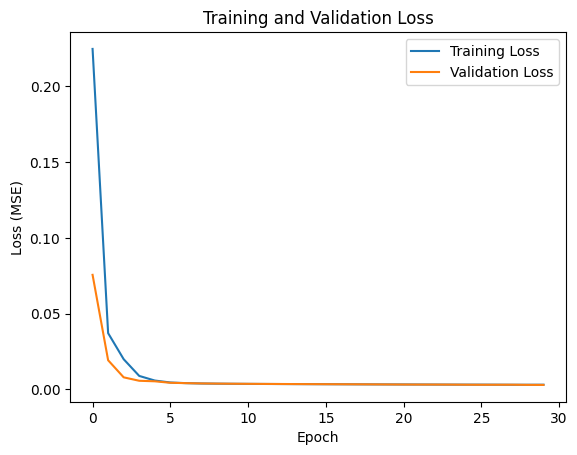

In [22]:
plot_train_loss(history)

In [23]:
model = Sequential()
model.add(Bidirectional(LSTM(100, activation='relu', input_shape=(window_size, 4))))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mse')


history = model.fit(train_dataset, epochs=30, validation_data=test_dataset, batch_size=1, callbacks=[early_stopping])


Epoch 1/30
37/37 [==============================] - 4s 24ms/step - loss: 0.1690 - val_loss: 0.0201
Epoch 2/30
37/37 [==============================] - 0s 10ms/step - loss: 0.0280 - val_loss: 0.0139
Epoch 3/30
37/37 [==============================] - 0s 11ms/step - loss: 0.0129 - val_loss: 0.0056
Epoch 4/30
37/37 [==============================] - 0s 11ms/step - loss: 0.0056 - val_loss: 0.0045
Epoch 5/30
37/37 [==============================] - 0s 11ms/step - loss: 0.0039 - val_loss: 0.0039
Epoch 6/30
37/37 [==============================] - 0s 10ms/step - loss: 0.0034 - val_loss: 0.0034
Epoch 7/30
37/37 [==============================] - 0s 11ms/step - loss: 0.0032 - val_loss: 0.0033
Epoch 8/30
37/37 [==============================] - 0s 10ms/step - loss: 0.0031 - val_loss: 0.0032
Epoch 9/30
37/37 [==============================] - 0s 10ms/step - loss: 0.0031 - val_loss: 0.0032
Epoch 10/30
37/37 [==============================] - 0s 11ms/step - loss: 0.0031 - val_loss: 0.0032
Epoch 11/

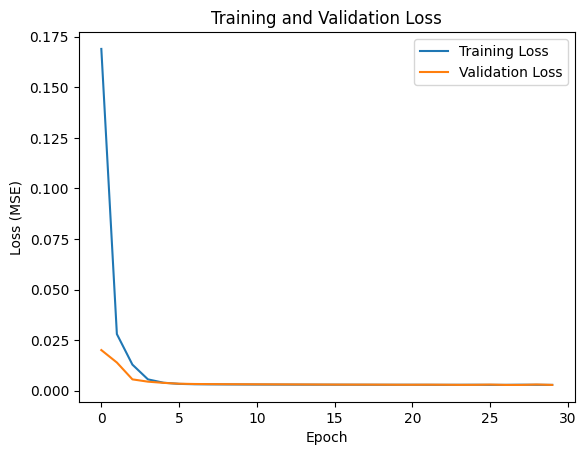

In [24]:
plot_train_loss(history)

In [25]:
gru_model = Sequential()
gru_model.add(GRU(100, activation='relu', input_shape=(window_size,4)))
gru_model.add(Dense(1))
gru_model.compile(optimizer='adam', loss='mse')

history = gru_model.fit(train_dataset, epochs=30, validation_data=test_dataset, batch_size=1, callbacks=[early_stopping])

Epoch 1/30
37/37 [==============================] - 2s 15ms/step - loss: 0.1519 - val_loss: 0.0180
Epoch 2/30
37/37 [==============================] - 0s 8ms/step - loss: 0.0262 - val_loss: 0.0121
Epoch 3/30
37/37 [==============================] - 0s 8ms/step - loss: 0.0114 - val_loss: 0.0056
Epoch 4/30
37/37 [==============================] - 0s 8ms/step - loss: 0.0055 - val_loss: 0.0044
Epoch 5/30
37/37 [==============================] - 0s 9ms/step - loss: 0.0041 - val_loss: 0.0039
Epoch 6/30
37/37 [==============================] - 0s 12ms/step - loss: 0.0037 - val_loss: 0.0036
Epoch 7/30
37/37 [==============================] - 1s 18ms/step - loss: 0.0035 - val_loss: 0.0035
Epoch 8/30
37/37 [==============================] - 1s 14ms/step - loss: 0.0034 - val_loss: 0.0034
Epoch 9/30
37/37 [==============================] - 1s 14ms/step - loss: 0.0033 - val_loss: 0.0033
Epoch 10/30
37/37 [==============================] - 0s 11ms/step - loss: 0.0032 - val_loss: 0.0032
Epoch 11/30
3

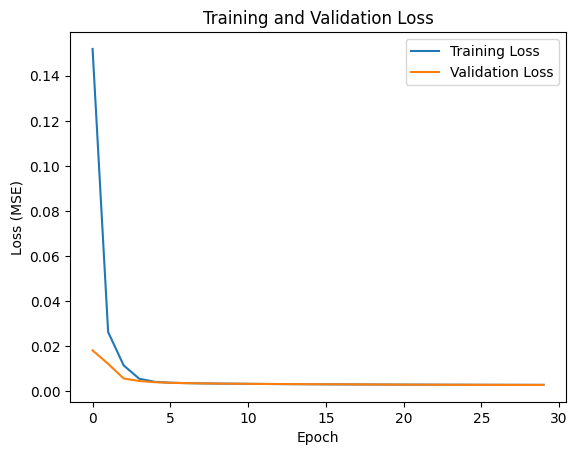

In [26]:
plot_train_loss(history)

In [35]:
test_features, test_labels = [], []
for x, y in test_dataset:
    test_features.append(x.numpy())
    test_labels.append(y.numpy())

In [54]:
lstm_pred = lstm_model.predict(test_dataset)

lstm_pred= np.vstack(lstm_pred)
lstm_pred= temp_scaler.inverse_transform(lstm_pred)



test_labels = np.concatenate(test_labels)
test_labels = np.vstack(test_labels)







10/10 [==============================] - 0s 6ms/step


In [39]:
# Convert the test_labels list to a NumPy array
test_labels = np.array(test_labels)

# Concatenate the arrays along the first dimension
test_labels = np.vstack(test_labels)

test_labels=temp_scaler.inverse_transform(test_labels)

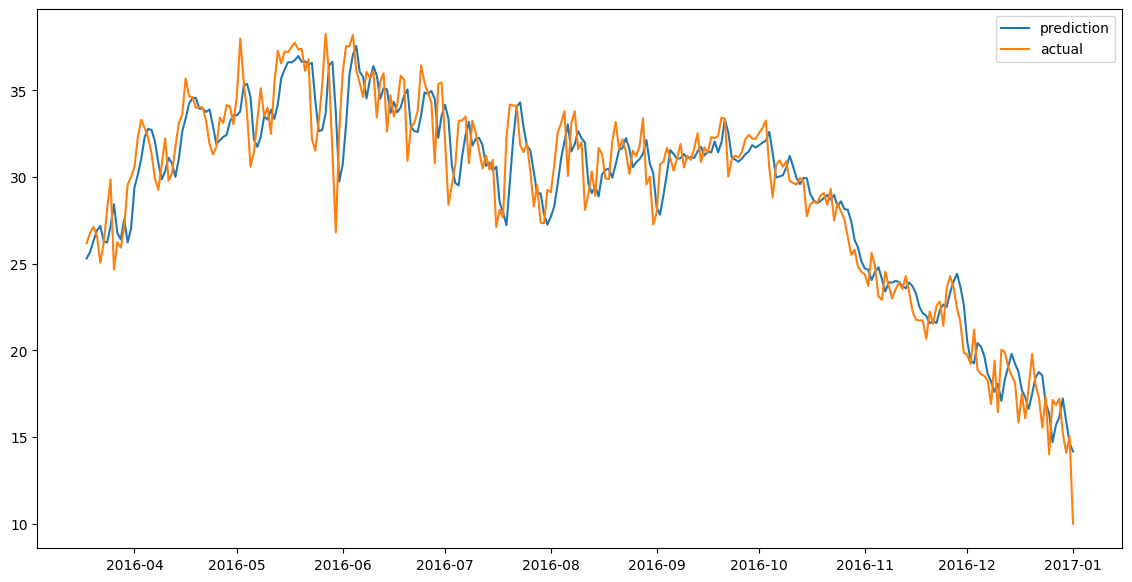

In [55]:
plt.figure(figsize=(14, 7))
plt.plot(data.index[-len(test_labels):],lstm_pred,label="prediction")
plt.plot(data.index[-len(test_labels):],test_labels,label="actual")
plt.legend()


In [57]:
rmse_lstm = np.sqrt(mean_squared_error(lstm_pred, test_labels))
r2_lstm = r2_score(lstm_pred, test_labels)
print(f'RMSE: {rmse_lstm}')
print(f'R2 Score: {r2_lstm}')

RMSE: 1.7638953753374473
R2 Score: 0.890150011861997


In [60]:
bilstm_pred = model.predict(test_dataset)

bilstm_pred = np.vstack(bilstm_pred)
bilstm_pred= temp_scaler.inverse_transform(bilstm_pred)

10/10 [==============================] - 0s 5ms/step


In [61]:
rmse_bilstm = np.sqrt(mean_squared_error(bilstm_pred, test_labels))
r2_bilstm = r2_score(bilstm_pred, test_labels)

print(f'RMSE: {rmse_bilstm}')
print(f'R2 Score: {r2_bilstm}')

RMSE: 1.7464245335391868
R2 Score: 0.891606853047416


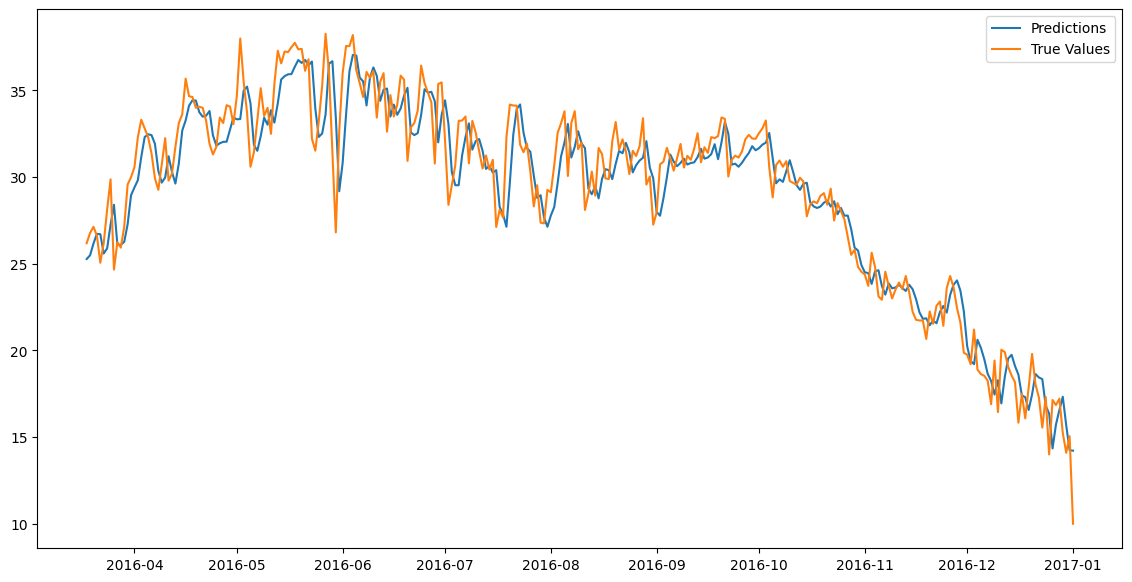

In [63]:

plt.figure(figsize=(14, 7))
plt.plot(data.index[-len(bilstm_pred):], bilstm_pred, label='Predictions')
plt.plot(data.index[-len(bilstm_pred):], test_labels, label='True Values')

plt.legend()
plt.show()

# GRU

In [65]:
GRU_pred = lstm_model.predict(test_dataset)
GRU_pred = np.vstack(GRU_pred)
GRU_pred= temp_scaler.inverse_transform(GRU_pred)

10/10 [==============================] - 0s 5ms/step


In [66]:
rmse_GRU = np.sqrt(mean_squared_error(GRU_pred, test_labels))
r2_GRU = r2_score(GRU_pred, test_labels)

print(f'RMSE: {rmse_GRU}')
print(f'R2 Score: {r2_GRU}')

RMSE: 1.7638953753374473
R2 Score: 0.890150011861997


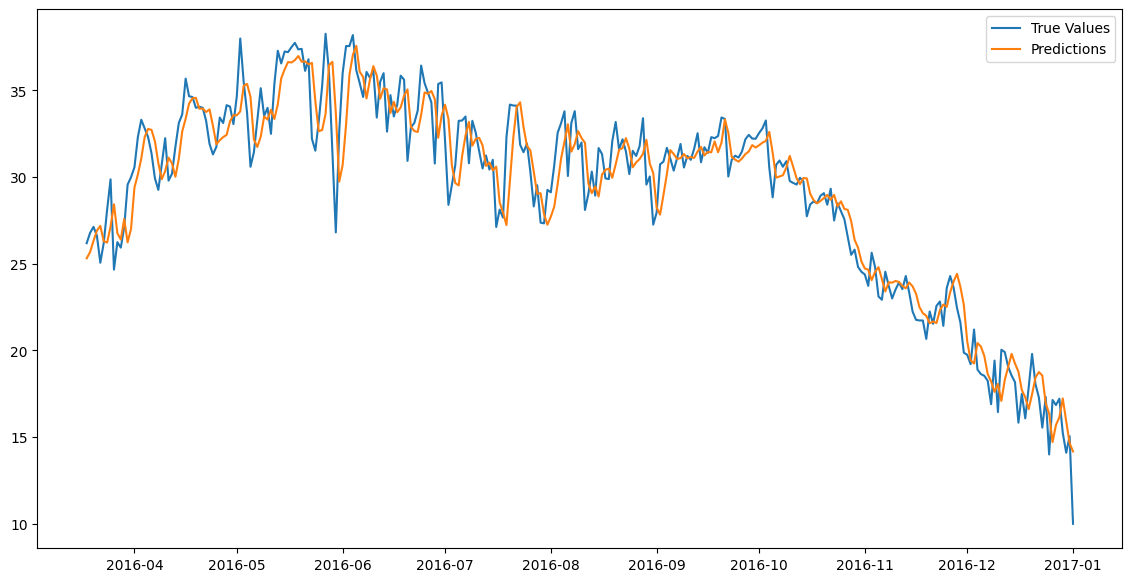

In [67]:
plt.figure(figsize=(14, 7))
plt.plot(data.index[-len(GRU_pred):], test_labels, label='True Values')
plt.plot(data.index[-len(GRU_pred):], GRU_pred, label='Predictions')

plt.legend()
plt.show()

([<matplotlib.axis.XTick at 0x7d883d0752a0>,
 [Text(0, 0, 'rmse_lstm'), Text(1, 0, 'rmse_bilstm'), Text(2, 0, 'rmse_GRU')])

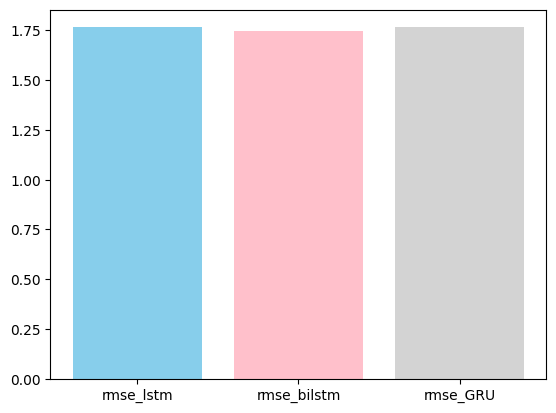

In [68]:
labels=["rmse_lstm","rmse_bilstm","rmse_GRU"]
plt.bar(range(3),[rmse_lstm,rmse_bilstm,rmse_GRU],color=['skyblue', 'pink', 'lightgrey'])
plt.xticks( range(3),labels=labels)

([<matplotlib.axis.XTick at 0x7d883d0d6fe0>,
 [Text(0, 0, 'r2_lstm'), Text(1, 0, 'r2_bilstm'), Text(2, 0, 'r2_GRU')])

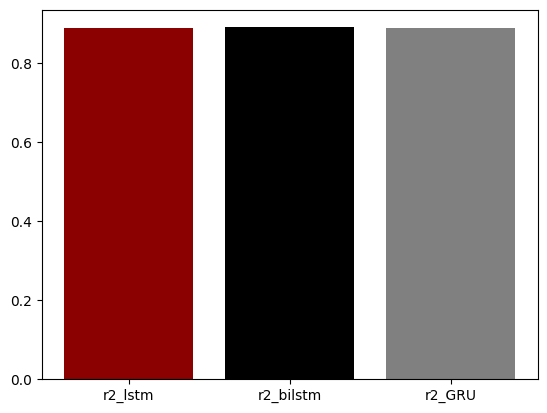

In [69]:
labels=["r2_lstm","r2_bilstm","r2_GRU"]
plt.bar(range(3),[r2_lstm,r2_bilstm,r2_GRU],color=['darkred', 'black', 'grey'])
plt.xticks( range(3),labels=labels)